# 03 - Training, Loss, and Generalization

## Goals

- Understand training vs testing data
- Understand what overfitting is
- Understand what underfitting is
- Understand why low training loss is not enough
- Understand validation data
- Understand epochs and batch size
- Understand learning rate more deeply
- Understand why models can generalize to unseen inputs
- Learn how to inspect training behavior with loss curves

Epoch: 0Training Loss: 10.666053Validation Loss: 287.738525
Epoch: 100Training Loss: 0.515469Validation Loss: 9.176639
Epoch: 200Training Loss: 0.244555Validation Loss: 6.698088
Epoch: 300Training Loss: 0.223548Validation Loss: 6.520016
Epoch: 400Training Loss: 0.216215Validation Loss: 6.879442
Epoch: 500Training Loss: 0.212013Validation Loss: 6.520931
Epoch: 600Training Loss: 0.210545Validation Loss: 6.235268
Epoch: 700Training Loss: 0.209570Validation Loss: 6.239086
Epoch: 800Training Loss: 0.208738Validation Loss: 6.212692
Epoch: 900Training Loss: 0.207902Validation Loss: 6.114679


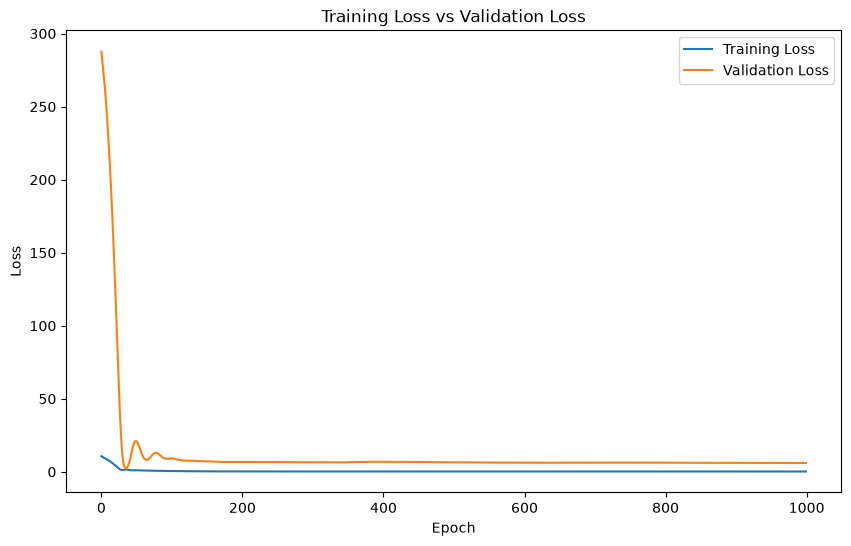

Prediciton for x = 2.5: 8.945024490356445
Underlying rule gives: 9.125


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Make results repeatable
torch.manual_seed(42)

#------------
# CREATE DATA
#------------

# 80 input values from -5 to 5
x = torch.linspace(-5, 5, 80).reshape(-1, 1)

# The hidden rule we want the network to learn
y = 0.5 * x**2 + 2 * x + 1

# Add a little random noise so the data isnt perfect
noise = torch.randn_like(y) * 0.5
y = y + noise

#------------
# SPLIT DATA
#-----------

# First 60 examples are training data
x_train = x[:60]
y_train = y[:60]

# Last 20 examples are validation data
x_val = x[60:]
y_val = y[60:]

# move everything to the gpu
x_train = x_train.to("cuda")
y_train = y_train.to("cuda")
x_val = x_val.to("cuda")
y_val = y_val.to("cuda")


#----------
# CREATE MODEL
# --------------

class Network(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(1, 16)
        self.relu1 = nn.ReLU()

        self.layer2 = nn.Linear(16, 16)
        self.relu2 = nn.ReLU()

        self.layer3 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)

        x = self.layer2(x)
        x = self.relu2(x)

        x = self.layer3(x)

        return x

model = Network().to("cuda")

# -------------
# LOSS AND OPTIMIZER
# --------------

loss_function = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# --------
# STROE LOSS HISTORY
# ------------

training_losses = []
validation_losses = []

# ----------------
# TRAIN MODEL
# ---------------

for epoch in range(1000):

    # Put model into training mode
    model.train()

    # Clear old gradients
    optimizer.zero_grad()

    # Make predictions on training data
    train_predictions = model(x_train)

    # Calculate the training loss
    train_loss = loss_function(
        train_predictions,
        y_train
    )

    # Calculate the gradients
    train_loss.backward()

    # Update weights and biases
    optimizer.step()

    # ---------------
    # VALIDATION
    #-------------

    # Put model into evaluation mode
    model.eval()

    with torch.no_grad():

        # Make predictions on the data the model is NOT training on
        val_predictions = model(x_val)

        # Measure how well it performs on unseen validation data
        val_loss = loss_function(
            val_predictions,
            y_val
        )

    # Save losses so we can graph them later
    training_losses.append(train_loss.item())
    validation_losses.append(val_loss.item())

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}"
        f"Training Loss: {train_loss.item():.6f}"
        f"Validation Loss: {val_loss.item():.6f}")

# -----------
# PLOT LOSS
# ----------

plt.figure(figsize=(10 ,6))

plt.plot(training_losses,
label="Training Loss")

plt.plot(validation_losses,
label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()

plt.show()

# ------------------
# TEST WITH A NEW VALUE
# ------------------

test_input = torch.tensor([[2.5]], device="cuda")

model.eval()

with torch.no_grad():
    test_prediction = model(test_input)

print("Prediciton for x = 2.5:", test_prediction.item())

# Calculate what the original rule says
expected = 0.5 * (2.5**2) + 2 * 2.5 + 1
print("Underlying rule gives:", expected)